In [14]:
import pandas as pd

data = {
    "Column":  ["CRIM", "RM", "AGE", "DIS", "TAX", "PTRATIO", "PRICE"],
    "Meaning": ["Crime rate per town", "Average number of rooms", "Age of the house",
                "Distance to employment centres", "Property tax rate",
                "Pupil-teacher ratio", "House price — this is what we predict!"]
}

pd.DataFrame(data)

,Column,Meaning
0,CRIM,Crime rate per town
1,RM,Average number of rooms
2,AGE,Age of the house
3,DIS,Distance to employment centres
4,TAX,Property tax rate
5,PTRATIO,Pupil-teacher ratio
6,PRICE,House price — this is what we predict!


In [15]:


# Add proper column names manually
columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 
           'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'PRICE']

df = pd.read_csv(r'C:\Users\sandu\Downloads\Data Set For Task\4) house Prediction Data Set.csv', 
                 sep=r'\s+',
                 engine='python',
                 names=columns)

print(df.head())
print(df.shape)
print(df.columns.tolist())


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  
(506, 14)
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'PRICE']


In [12]:
print("Missing values:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

Total missing values: 0


In [13]:
print(df.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

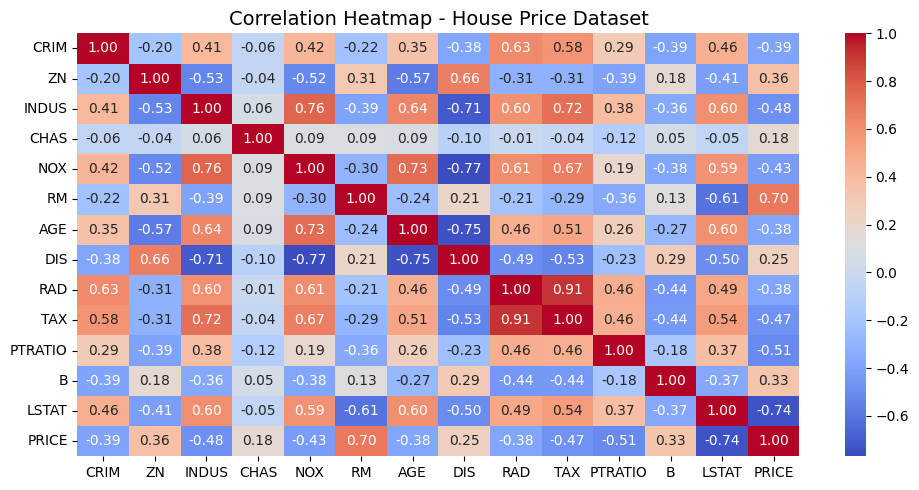

Heatmap saved!


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - House Price Dataset', fontsize=14)
plt.tight_layout()
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 2\correlation_heatmap.png')
plt.show()
print("Heatmap saved!")

In [21]:
from sklearn.model_selection import train_test_split

# X = all columns except PRICE
# y = PRICE column only
X = df.drop(columns=['PRICE'])
y = df['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                      test_size=0.2, 
                                                      random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (404, 13)
Testing set size: (102, 13)


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")  #train the linear regression model

Model trained successfully!


In [23]:
# evaluate the modle

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Model Performance:")
print(f"R-Squared Score : {r2:.4f}")
print(f"Mean Squared Error : {mse:.4f}")
print(f"Root Mean Squared Error : {rmse:.4f}")

Model Performance:
R-Squared Score : 0.6688
Mean Squared Error : 24.2911
Root Mean Squared Error : 4.9286


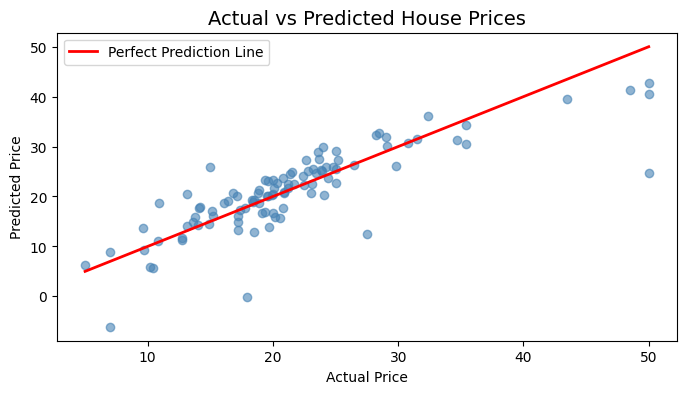

Chart saved!


In [29]:
#Chart for Actual vs Predicted prices

plt.figure(figsize=(8, 4))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', linewidth=2, label='Perfect Prediction Line')
plt.title('Actual vs Predicted House Prices', fontsize=14)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 2\actual_vs_predicted.png')
plt.show()
print("Chart saved!")

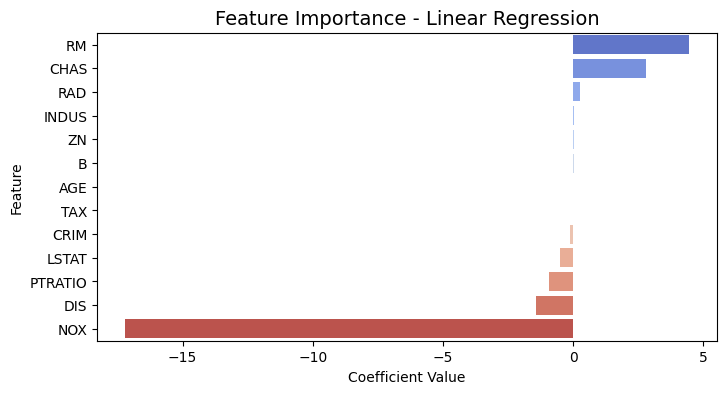

Feature importance chart saved!


In [28]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=coefficients, x='Coefficient', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title('Feature Importance - Linear Regression', fontsize=14)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 2\feature_importance.png')
plt.show()
print("Feature importance chart saved!")